# Training Keyword Spotting Model with 8-bit Mamba Block

# Integrating 8-bit Mamba C Implementation with Python

In this notebook, we’ll load the 8-bit Mamba model implemented in C as a shared library, define Python wrapper functions, and run an example forward pass.

### Step 1: Load Required Libraries

In [1]:
import ctypes
import numpy as np


### Step 2: Load the Shared Library and Define the C Function Signatures

We load the compiled shared library (`libmamba_model.so`) and define the function signatures for `mamba_init` and `mamba_forward` using Python’s `ctypes` library.

In [2]:
# Load the shared library
mamba_lib = ctypes.CDLL('./8bit/libmamba_model.so')  # Adjust path if necessary

# Define argument and return types for the functions
mamba_lib.mamba_init.restype = None
mamba_lib.mamba_forward.argtypes = [
    np.ctypeslib.ndpointer(dtype=np.int8, ndim=3, flags="C_CONTIGUOUS"),  # Input
    np.ctypeslib.ndpointer(dtype=np.int8, ndim=3, flags="C_CONTIGUOUS")   # Output
]
mamba_lib.mamba_forward.restype = None  # No return value


### Step 3: Create Python Wrapper Functions for Initialization and Forward Pass

Define wrapper functions to initialize the model parameters (`mamba_init`) and perform the forward pass (`mamba_forward`).

In [3]:
# Initialize the Mamba model parameters
def mamba_init():
    """Initialize the 8-bit Mamba model parameters."""
    mamba_lib.mamba_init()

# Perform the forward pass
def mamba_forward(input_array, output_shape):
    """
    Perform the forward pass.
    
    Parameters:
        input_array (np.ndarray): The input data of shape (BATCH_SIZE, SEQ_LENGTH, INPUT_DIM)
        output_shape (tuple): The shape of the output array.
    
    Returns:
        np.ndarray: The output data.
    """
    # Ensure the input is a contiguous array of type int8
    input_array = np.ascontiguousarray(input_array, dtype=np.int8)
    
    # Create an empty output array with the correct shape and type
    output_array = np.zeros(output_shape, dtype=np.int8)
    
    # Call the C function
    mamba_lib.mamba_forward(input_array, output_array)
    
    return output_array


### Step 4: Set Up Parameters and Test the Forward Pass

Initialize the model, create sample input data, and run the forward pass to ensure the integration works correctly.

In [4]:
# Define model parameters
BATCH_SIZE = 4
SEQ_LENGTH = 10
INPUT_DIM = 8
STATE_DIM = 16
OUTPUT_DIM = 5

# Initialize the Mamba model
mamba_init()

# Create a sample input array with random values
input_array = np.random.randint(-128, 127, (BATCH_SIZE, SEQ_LENGTH, INPUT_DIM), dtype=np.int8)

# Define the output shape
output_shape = (BATCH_SIZE, SEQ_LENGTH, OUTPUT_DIM)

# Perform the forward pass
output_array = mamba_forward(input_array, output_shape)

print("Output from 8-bit Mamba forward pass:", output_array)


Output from 8-bit Mamba forward pass: [[[ -4  -4 -15 -15   0]
  [  0   0   0   0   0]
  [  0   0   0   0   0]
  [  0   0   0   0   0]
  [  0   0   0   0   0]
  [  0   0   0   0   0]
  [  0   0   0   0   0]
  [  0   0   0   0   0]
  [  0   0   0   0   0]
  [  0   0   0   0   0]]

 [[  0   0   0   0   0]
  [  0   0   0   0   0]
  [  0   0   0   0   0]
  [  0   0   0   0   0]
  [  0   0   0   0   0]
  [  0   0   0   0   0]
  [  0   0   0   0   0]
  [  0   0   0   0   0]
  [  0   0   0   0   0]
  [  0   0   0   0   0]]

 [[  0   0   0   0   0]
  [  0   0   0   0   0]
  [  0   0   0   0   0]
  [  0   0   0   0   0]
  [  0   0   0   0   0]
  [  0   0   0   0   0]
  [  0   0   0   0   0]
  [  0   0   0   0   0]
  [  0   0   0   0   0]
  [  0   0   0   0   0]]

 [[  0   0   0   0   0]
  [  0   0   0   0   0]
  [  0   0   0   0   0]
  [  0   0   0   0   0]
  [  0   0   0   0   0]
  [  0   0   0   0   0]
  [  0   0   0   0   0]
  [  0   0   0   0   0]
  [  0   0   0   0   0]
  [  0   0   0   0  

In [5]:
import torch
import numpy as np
from torch.utils.data import DataLoader, Dataset
import torch.optim as optim
import torch.nn as nn
import pandas as pd

# Import KWS model and utilities
from src.data.data_loader import load_speech_commands_dataset
from src.utils.utils import set_memory_GB, print_model_size, plot_learning_curves
from src.utils.augmentations import add_time_shift_and_align, add_noise
from src.utils.train_utils import trainig_loop
from src.utils.utils import compute_inference_GPU_mem

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
set_memory_GB(1)

/usr/local/lib/python3.10/dist-packages/mamba_ssm/ops/selective_scan_interface.py:164: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  def forward(ctx, xz, conv1d_weight, conv1d_bias, x_proj_weight, delta_proj_weight,
/usr/local/lib/python3.10/dist-packages/mamba_ssm/ops/selective_scan_interface.py:240: FutureWarning: `torch.cuda.amp.custom_bwd(args...)` is deprecated. Please use `torch.amp.custom_bwd(args..., device_type='cuda')` instead.
  def backward(ctx, dout):
/usr/local/lib/python3.10/dist-packages/mamba_ssm/ops/triton/layer_norm.py:986: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  def forward(
/usr/local/lib/python3.10/dist-packages/mamba_ssm/ops/triton/layer_norm.py:1045: FutureWarning: `torch.cuda.amp.custom_bwd(args...)` is deprecated. Please use `torch.amp.custom_bwd(args..., device_type=

Device: cuda
Memory fraction set to 0.022458079576498518
Memory fraction in GB: 1.0


### Load Dataset and Apply Augmentations

In [13]:
# Load dataset
train_ds, val_ds, test_ds, silence_ds, info = load_speech_commands_dataset(reduced=True)

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(0)
label_names = info.features['label'].names[:10]
print("Label names:", label_names)

# Define augmentations
augmentations = [
    lambda x: add_time_shift_and_align(x),
    lambda x: add_noise(x, noise_level=0.01)
]

Label names: ['down', 'go', 'left', 'no', 'off', 'on', 'right', 'stop', 'up', 'yes']


### Define Dataset Adapter

In [14]:
from librosa.feature import mfcc, delta

class TFDatasetAdapter(Dataset):
    def __init__(self, tf_dataset, fixed_length, n_mfcc, n_fft, hop_length, n_mels, augmentations=None):
        self.tf_dataset = tf_dataset
        self.data = list(tf_dataset)
        self.fixed_length = fixed_length
        self.n_mfcc = n_mfcc
        self.n_fft = n_fft
        self.hop_length = hop_length
        self.n_mels = n_mels
        self.augmentations = augmentations

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        audio, label = self.data[idx]
        audio = audio.numpy().astype(np.float32)

        # Apply augmentations
        if self.augmentations:
            for aug in self.augmentations:
                audio = aug(audio)

        # Pad or trim audio
        if len(audio) < self.fixed_length:
            audio = np.pad(audio, (0, self.fixed_length - len(audio)), mode='constant')
        else:
            audio = audio[:self.fixed_length]

        # Compute MFCCs
        MFCC = mfcc(y=audio, sr=16000, n_mfcc=self.n_mfcc, n_fft=self.n_fft, hop_length=self.hop_length, n_mels=self.n_mels)
        MFCC_delta = delta(MFCC)
        MFCC_delta2 = delta(MFCC, order=2)
        MFCC = np.vstack([MFCC, MFCC_delta, MFCC_delta2])

        return torch.tensor(MFCC, dtype=torch.float32), torch.tensor(label.numpy(), dtype=torch.long)

### Convert Dataset to PyTorch Format

In [15]:
# Set parameters
fixed_length = 16000
n_mfcc = 13
n_fft = 640
hop_length = 320
n_mels = 40
batch_size = 16

# Prepare PyTorch Datasets
pytorch_train_dataset = TFDatasetAdapter(train_ds, fixed_length, n_mfcc, n_fft, hop_length, n_mels, augmentations)
pytorch_val_dataset = TFDatasetAdapter(val_ds, fixed_length, n_mfcc, n_fft, hop_length, n_mels)

# DataLoaders
train_loader = DataLoader(pytorch_train_dataset, batch_size=batch_size, shuffle=True, num_workers=4)
val_loader = DataLoader(pytorch_val_dataset, batch_size=batch_size, shuffle=False, num_workers=4)

2024-11-10 08:38:41.985854: I tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


### Initialize Keyword Spotting Model with 8-bit Mamba Block

In [16]:
import torch
import torch.nn as nn

class KeywordSpottingModel_with_cls(nn.Module):
    def __init__(self, input_dim, d_model, d_state, d_conv, expand, label_names, num_mamba_layers=1, dropout_rate=0.2):
        super(KeywordSpottingModel_with_cls, self).__init__()
        
        # Initialize 8-bit Mamba model
        mamba_init()
        
        # Initial projection layer
        self.proj = nn.Linear(input_dim, d_model)  
        
        # CLS token: learnable parameter with shape [1, 1, d_model]
        self.cls_token = nn.Parameter(torch.zeros(1, 1, d_model))
        
        # Quantization stubs
        self.quant = torch.quantization.QuantStub()  # Quantize the input
        self.dequant = torch.quantization.DeQuantStub()  # Dequantize output if needed
        
        # Layer normalization for each Mamba layer output
        self.layer_norms = nn.ModuleList([
            nn.modules.normalization.RMSNorm(d_model) for _ in range(num_mamba_layers)
        ])

        # Output layer
        self.fc = nn.Linear(d_model, len(label_names))  
        self.dropout = nn.Dropout(dropout_rate)

    def forward(self, x):
        # Quantize the input
        x = self.quant(x)

        # Reshape to [batch_size, num_frames, num_mfcc]
        x = x.permute(0, 2, 1)
        
        # Project input to d_model dimension
        x = self.proj(x)  
        
        # Create a CLS token and expand it across the batch dimension
        batch_size = x.size(0)
        cls_tokens = self.cls_token.expand(batch_size, -1, -1)  # Shape: [batch_size, 1, d_model]
        
        # Append the CLS token to the input sequence
        x = torch.cat((x, cls_tokens), dim=1)  # Shape: [batch_size, num_frames + 1, d_model]
        x = x.permute(0, 2, 1)  # Transpose to [batch_size, d_model, num_frames + 1] for Mamba

        # Pass through Mamba layers and layer normalization
        for i, layer_norm in enumerate(self.layer_norms):
            # Convert x to int8 and pass through mamba_forward
            x_np = x.detach().cpu().numpy().astype(np.int8)  # Convert to int8 as required by mamba_forward
            output_shape = x_np.shape  # Define output shape for Mamba
            x_np = mamba_forward(x_np, output_shape)  # Pass through 8-bit Mamba in C
            x = torch.tensor(x_np, dtype=torch.float32, device=x.device)  # Convert back to tensor

            # Apply RMSNorm after each Mamba layer (on the last dimension only)
            x = x.permute(0, 2, 1)  # Shape [batch_size, num_frames + 1, d_model] for normalization
            x = layer_norm(x)  # Apply RMSNorm
            x = x.permute(0, 2, 1)  # Revert shape to [batch_size, d_model, num_frames + 1]

        x = self.dropout(x)  # Apply dropout after Mamba layers
        
        # Extract the CLS token output (last token)
        cls_output = x[:, :, -1]  # Shape: [batch_size, d_model]
        
        # Dequantize before the final fully connected layer
        cls_output = self.dequant(cls_output)
        
        # Pass through the output layer
        x = self.fc(cls_output)
        
        return x


In [17]:
mamba_init()  # Initialize the Mamba block

# Model configuration
input_dim = 39
d_model = 51
d_state = 256
d_conv = 64
expand = 4

# Instantiate model
model = KeywordSpottingModel_with_cls(input_dim=input_dim, d_model=d_model, d_state=d_state, d_conv=d_conv, expand=expand, label_names=label_names, num_mamba_layers=2).to(device)
sample_input = torch.randn(batch_size, input_dim, d_model).to(device)

print_model_size(model, input_size=sample_input)


[INFO] Register count_linear() for <class 'torch.nn.modules.linear.Linear'>.
[INFO] Register zero_ops() for <class 'torch.nn.modules.dropout.Dropout'>.

MACs: 1631184.0 Which are 0.001631184 Giga-MACs, Params: 2560.0



(1631184.0, 2560.0)

### Define Loss, Optimizer, and Training Loop

100%|██████████████████████████████████████████████████████████████████| 1924/1924 [01:55<00:00, 16.64it/s]

Epoch 1/100, Training Loss: 2.3032107083068816, Training Accuracy: 9.886574149306119%


Validation Loss: 2.301905191150205, Validation Accuracy: 10.180934377531731%
Learning rate after epoch 1: [0.0024]
Best model saved


100%|██████████████████████████████████████████████████████████████████| 1924/1924 [01:45<00:00, 18.30it/s]

Epoch 2/100, Training Loss: 2.3026541797386137, Training Accuracy: 10.185576391822938%


...

Epoch 5/100, Training Loss: 2.302613486866941, Training Accuracy: 10.491078683090123%


Validation Loss: 2.3019521483059586, Validation Accuracy: 10.721036997029435%
Learning rate after epoch 5: [0.00023999999999999998]


100%|██████████████████████████████████████████████████████████████████| 1924/1924 [02:00<00:00, 15.92it/s]

Epoch 6/100, Training Loss: 2.30231891464047, Training Accuracy: 10.491078683090123%


Validation Loss: 2.3020124825937995, Validation Accuracy: 10.721036997029435%
Learning rate after epoch 6: [0.00023999999999999998]
Early stopping triggered
Stopping training at epoch 6 due to early stopping


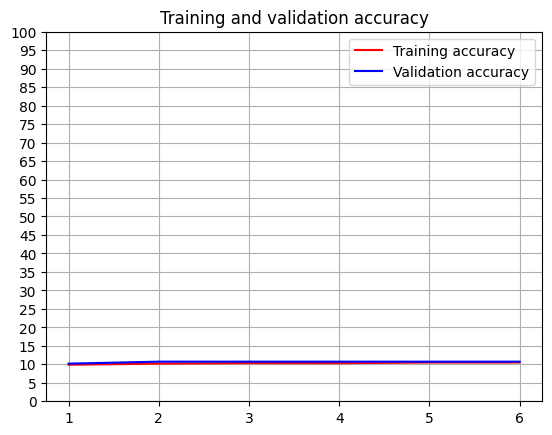

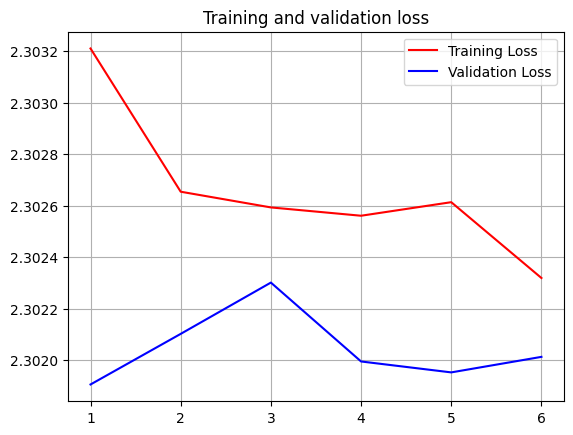

In [20]:
# Define loss, optimizer, and scheduler
criterion = nn.CrossEntropyLoss().to(device)
base_optimizer = optim.Adam(model.parameters(), lr=0.0024, weight_decay=2.80475e-05)
from torch_optimizer import Lookahead
optimizer = Lookahead(base_optimizer, k=5, alpha=0.5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3)

# Train model
num_epochs = 100
train_accuracies, val_accuracies, train_losses, val_losses = trainig_loop(model, num_epochs, train_loader, val_loader, criterion, optimizer, scheduler)

# Plot learning curves
plot_learning_curves(train_accuracies, val_accuracies, train_losses, val_losses)

### Save Model Results and Evaluate on Test Data

In [ ]:
# Calculate metrics and save results
test_dataset = TFDatasetAdapter(test_ds, fixed_length, n_mfcc, n_fft, hop_length, n_mels)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=4)

# Load best model for testing
model.load_state_dict(torch.load("best_model.pth"))

# Evaluate on test set
accuracy = 0
total = 0
model.eval()
with torch.no_grad():
    for audio, labels in test_loader:
        audio, labels = audio.to(device), labels.to(device)
        outputs = model(audio)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        accuracy += (predicted == labels).sum().item()

print(f'Test Accuracy: {100 * accuracy / total}%')